In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../datasets/england and wales/historic_demand_year_2024.csv')

In [3]:
df.head(5)

,settlement_date,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,nsl_flow,eleclink_flow,viking_flow,greenlink_flow
0,2024-01-01,1,21783,23466,19539,2804,6488,0,16726,0,...,417,-4,666,-179,-92,905,62,998,572,0
1,2024-01-01,2,22521,24103,20286,2834,6488,0,16726,0,...,430,-4,661,-60,-8,901,-15,998,575,0
2,2024-01-01,3,22194,24754,20070,2868,6488,0,16726,0,...,834,-4,661,-118,-1,807,-396,997,422,0
3,2024-01-01,4,21510,24505,19424,2901,6488,0,16726,0,...,839,-4,661,-270,-84,803,-473,997,401,0
4,2024-01-01,5,20619,23977,18674,2933,6488,0,16726,0,...,53,-5,661,-340,-103,537,-856,998,28,0


In [4]:
df1 = df[['england_wales_demand']].rename(columns={'england_wales_demand': 'demand'})
df1.head(5)

,demand
0,19539
1,20286
2,20070
3,19424
4,18674


In [5]:
df1.shape

(16320, 1)

In [6]:
df.tail(5)

,settlement_date,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,nsl_flow,eleclink_flow,viking_flow,greenlink_flow
16315,2024-12-05,44,29114,31431,27212,5377,6622,0,17194,0,...,558,758,1003,-450,-531,999,1397,0,1422,0
16316,2024-12-05,45,27204,29846,25477,5486,6622,0,17194,0,...,-193,263,1002,-450,-531,949,1397,0,1422,0
16317,2024-12-05,46,26006,28805,24428,5594,6622,0,17194,0,...,-274,211,997,-450,-531,943,1376,0,1414,0
16318,2024-12-05,47,23908,26825,22590,5575,6622,0,17194,0,...,-404,-77,280,-450,-522,338,1040,0,875,0
16319,2024-12-05,48,23217,26133,21958,5556,6622,0,17194,0,...,-415,-101,218,-450,-530,292,993,0,823,0


In [7]:
rng = pd.date_range('2024-01-01', periods=len(df1), freq='30min')
rng

DatetimeIndex(['2024-01-01 00:00:00', '2024-01-01 00:30:00',
               '2024-01-01 01:00:00', '2024-01-01 01:30:00',
               '2024-01-01 02:00:00', '2024-01-01 02:30:00',
               '2024-01-01 03:00:00', '2024-01-01 03:30:00',
               '2024-01-01 04:00:00', '2024-01-01 04:30:00',
               ...
               '2024-12-05 19:00:00', '2024-12-05 19:30:00',
               '2024-12-05 20:00:00', '2024-12-05 20:30:00',
               '2024-12-05 21:00:00', '2024-12-05 21:30:00',
               '2024-12-05 22:00:00', '2024-12-05 22:30:00',
               '2024-12-05 23:00:00', '2024-12-05 23:30:00'],
              dtype='datetime64[ns]', length=16320, freq='30min')

In [8]:
df1.set_index(rng, inplace=True)
df1.head(5)

,demand
2024-01-01 00:00:00,19539
2024-01-01 00:30:00,20286
2024-01-01 01:00:00,20070
2024-01-01 01:30:00,19424
2024-01-01 02:00:00,18674


In [9]:
df1.shape

(16320, 1)

In [10]:
df1['demand'].max()

41130

In [11]:
df1['demand'].min()

13740

In [12]:
df1['demand'].mean()

23921.26807598039

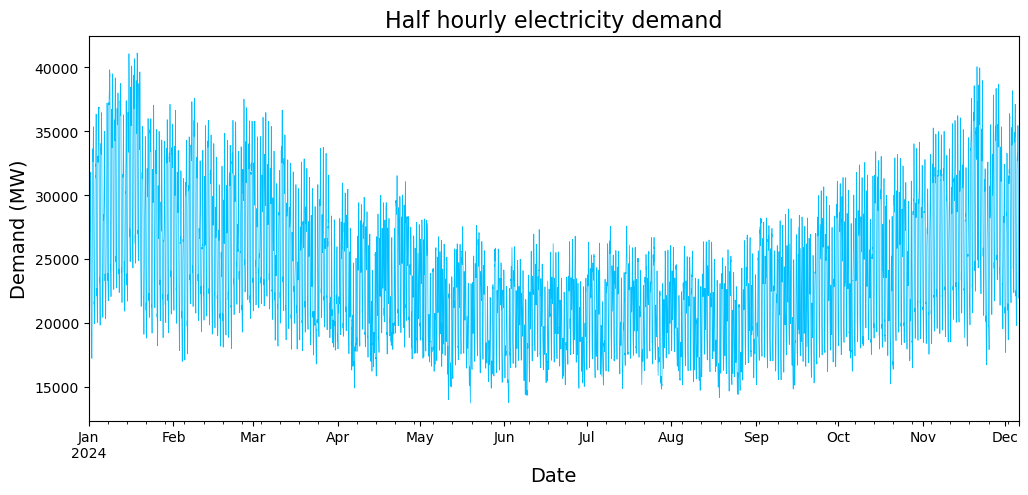

In [13]:
df1['demand'].plot(figsize=(12,5),linewidth= 0.5, color='deepskyblue')
plt.title('Half hourly electricity demand', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Demand (MW)', fontsize=14)
plt.show()

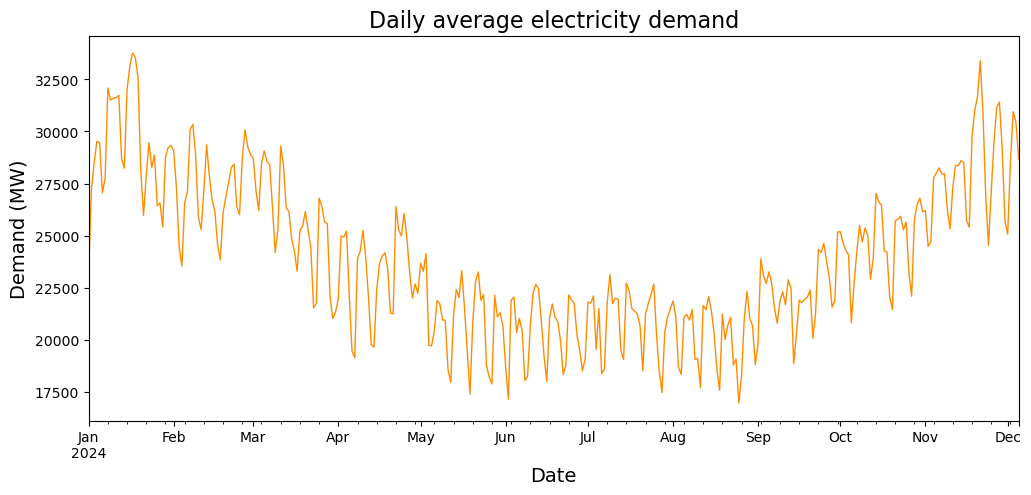

In [14]:
daily_avg = df1['demand'].resample('D').mean()
daily_avg.plot(figsize=(12,5), linewidth= 1, color='darkorange')
plt.title('Daily average electricity demand', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Demand (MW)', fontsize=14)
plt.show()

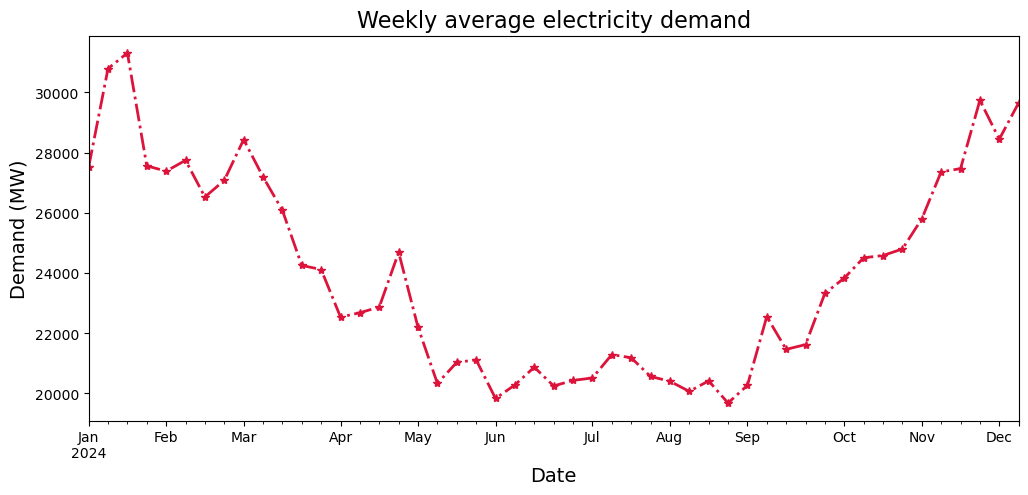

In [15]:
weekly_avg = df1['demand'].resample('W').mean()
weekly_avg.plot(figsize=(12,5), linewidth= 2, color='crimson', linestyle='-.', marker='*')
plt.title('Weekly average electricity demand', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Demand (MW)', fontsize=14)
plt.show()

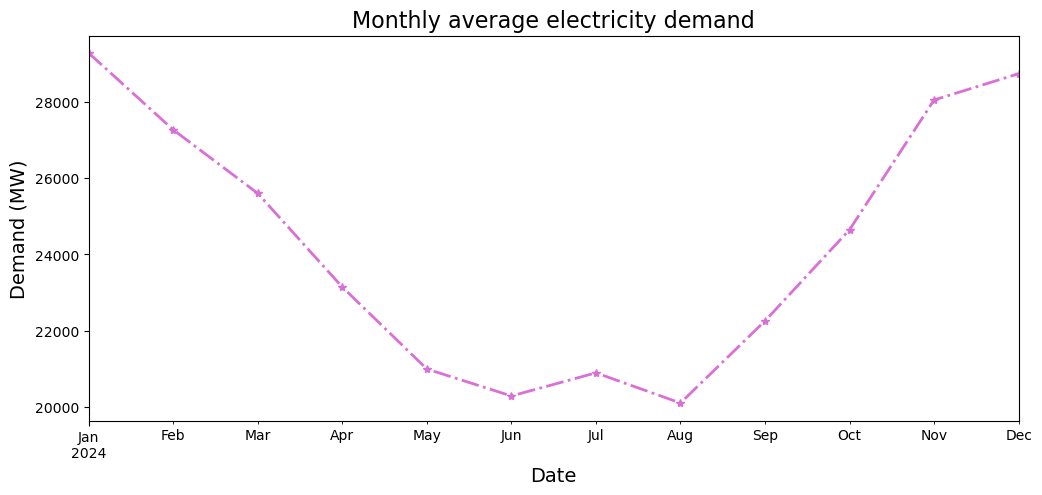

In [16]:
monthly_avg_demand = df1['demand'].resample('ME').mean()
monthly_avg_demand.plot(figsize=(12,5), linewidth= 2, color='orchid', linestyle='-.', marker='*')
plt.title('Monthly average electricity demand', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Demand (MW)', fontsize=14)
plt.show()

In [17]:
df1['demand'].describe()

count    16320.000000
mean     23921.268076
std       5363.233994
min      13740.000000
25%      19692.750000
50%      23077.000000
75%      27351.250000
max      41130.000000
Name: demand, dtype: float64

In [18]:
df1['demand'].std()

5363.233993856497

In [19]:
df1['demand'].skew()

0.6006092828243655

Text(0.5, 0, 'Demand (MW)')

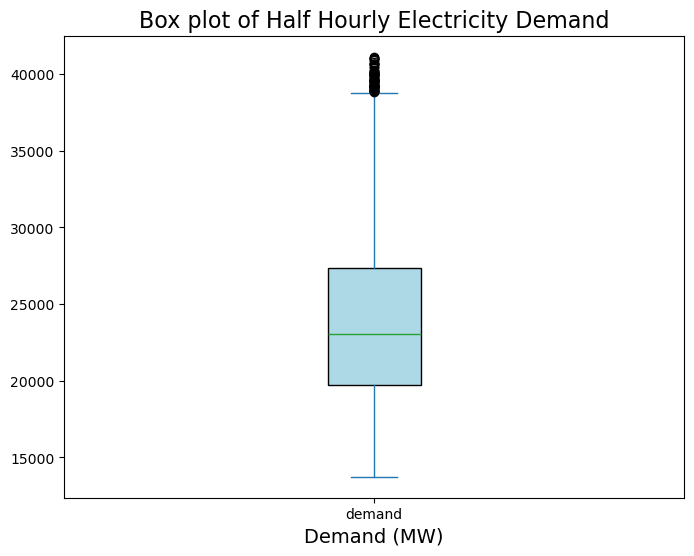

In [20]:
df1['demand'].plot(kind='box', figsize=(8,6), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box plot of Half Hourly Electricity Demand', fontsize=16)
plt.xlabel('Demand (MW)', fontsize=14)

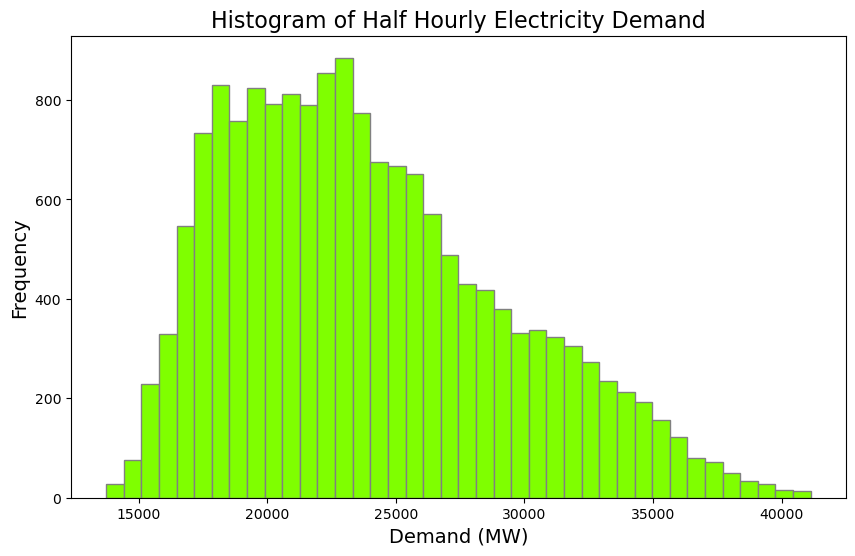

In [21]:
df1['demand'].plot(kind='hist', bins=40, figsize=(10,6), color='chartreuse', edgecolor='gray', linewidth=1)
plt.title('Histogram of Half Hourly Electricity Demand', fontsize=16)
plt.xlabel('Demand (MW)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

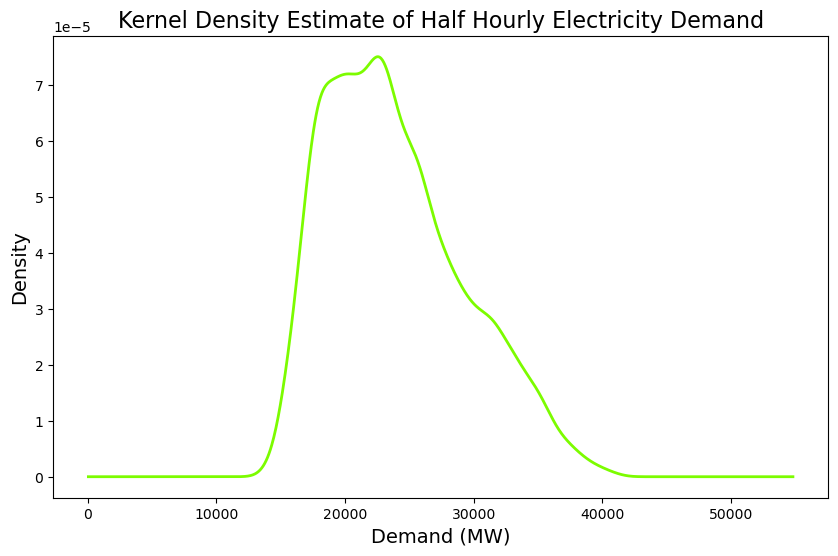

In [22]:
df1['demand'].plot(kind='kde', figsize=(10,6), color='lawngreen', linewidth=2)
plt.title('Kernel Density Estimate of Half Hourly Electricity Demand', fontsize=16)
plt.xlabel('Demand (MW)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.show()

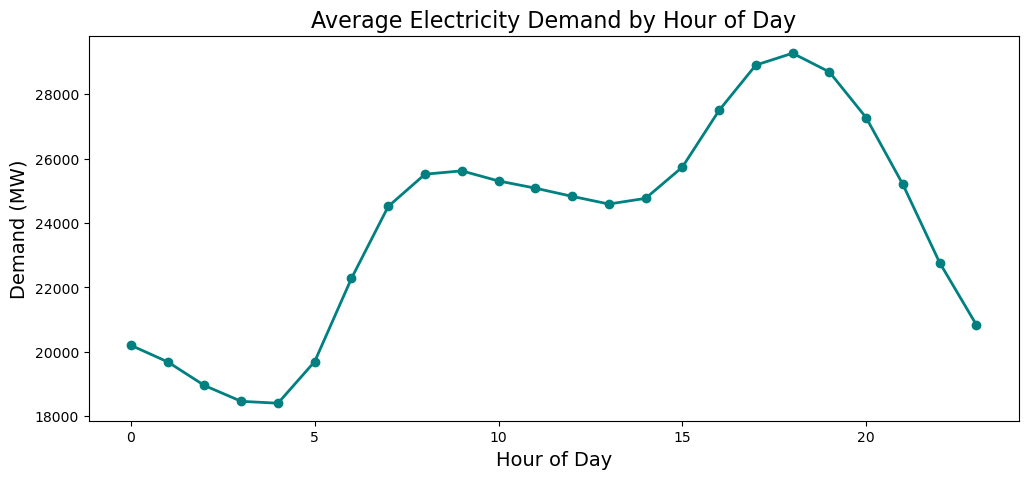

In [23]:
df1['hour'] = df1.index.hour
hourly_avg = df1.groupby('hour')['demand'].mean()
hourly_avg.plot(figsize=(12,5), linewidth= 2, color='teal', marker='o')
plt.title('Average Electricity Demand by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)  
plt.ylabel('Demand (MW)', fontsize=14)
plt.show()

In [24]:
df1.index

DatetimeIndex(['2024-01-01 00:00:00', '2024-01-01 00:30:00',
               '2024-01-01 01:00:00', '2024-01-01 01:30:00',
               '2024-01-01 02:00:00', '2024-01-01 02:30:00',
               '2024-01-01 03:00:00', '2024-01-01 03:30:00',
               '2024-01-01 04:00:00', '2024-01-01 04:30:00',
               ...
               '2024-12-05 19:00:00', '2024-12-05 19:30:00',
               '2024-12-05 20:00:00', '2024-12-05 20:30:00',
               '2024-12-05 21:00:00', '2024-12-05 21:30:00',
               '2024-12-05 22:00:00', '2024-12-05 22:30:00',
               '2024-12-05 23:00:00', '2024-12-05 23:30:00'],
              dtype='datetime64[ns]', length=16320, freq='30min')

In [28]:
df1.index.dayofweek

Index([0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       ...
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
      dtype='int32', length=16320)

In [32]:
df1.index.day_name()

Index(['Monday', 'Monday', 'Monday', 'Monday', 'Monday', 'Monday', 'Monday',
       'Monday', 'Monday', 'Monday',
       ...
       'Thursday', 'Thursday', 'Thursday', 'Thursday', 'Thursday', 'Thursday',
       'Thursday', 'Thursday', 'Thursday', 'Thursday'],
      dtype='object', length=16320)

In [33]:
df1.head(5)

,demand,hour
2024-01-01 00:00:00,19539,0
2024-01-01 00:30:00,20286,0
2024-01-01 01:00:00,20070,1
2024-01-01 01:30:00,19424,1
2024-01-01 02:00:00,18674,2


In [34]:
df1['day'] = df1.index.day_name()

In [35]:
df1.head(2)

,demand,hour,day
2024-01-01 00:00:00,19539,0,Monday
2024-01-01 00:30:00,20286,0,Monday


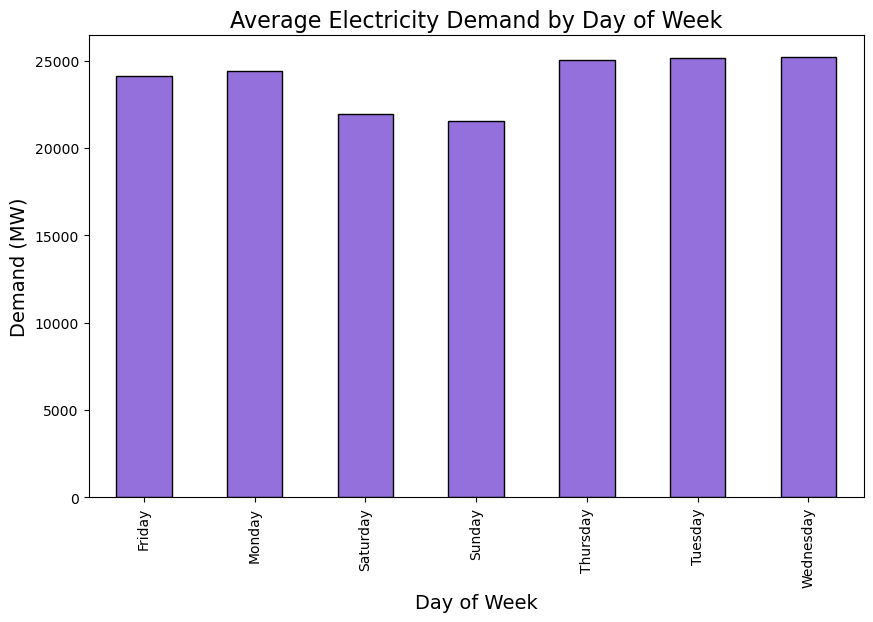

In [36]:
daily_avg = df1.groupby('day')['demand'].mean()
daily_avg.plot(kind='bar', figsize=(10,6), color='mediumpurple', edgecolor='black')
plt.title('Average Electricity Demand by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=14)
plt.ylabel('Demand (MW)', fontsize=14)
plt.show()